In [ ]:
!pip install mediapipe==0.10.35 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
!pip install kagglehub tensorflow mediapipe numpy matplotlib

In [ ]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("dataset path:", path)

100%|██████████| 1.03G/1.03G [00:12<00:00, 85.1MB/s]

Extracting files...


dataset path: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1


In [ ]:
import os

dataset_path = path

for folder in os.listdir(dataset_path):
  print(folder)

asl_alphabet_train
asl_alphabet_test


In [ ]:
train_path = os.path.join(dataset_path, "asl_alphabet_train", "asl_alphabet_train")

# Kitne letters hain
labels = sorted(os.listdir(train_path))
print("Total classes:", len(labels))
print("Labels:", labels)

Total classes: 29
Labels: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


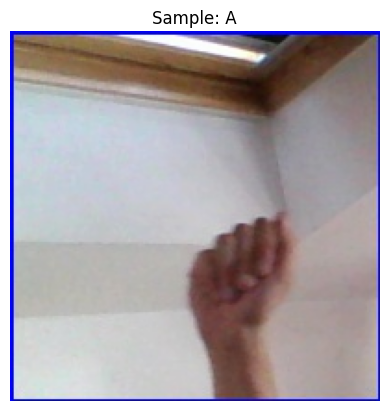

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample_letter = "A"
letter_path = os.path.join(train_path, sample_letter)
first_image = os.path.join(letter_path, os.listdir(letter_path)[0])
img = mpimg.imread(first_image)
plt.imshow(img)
plt.title(f"Sample: {sample_letter}")
plt.axis('off')
plt.show()

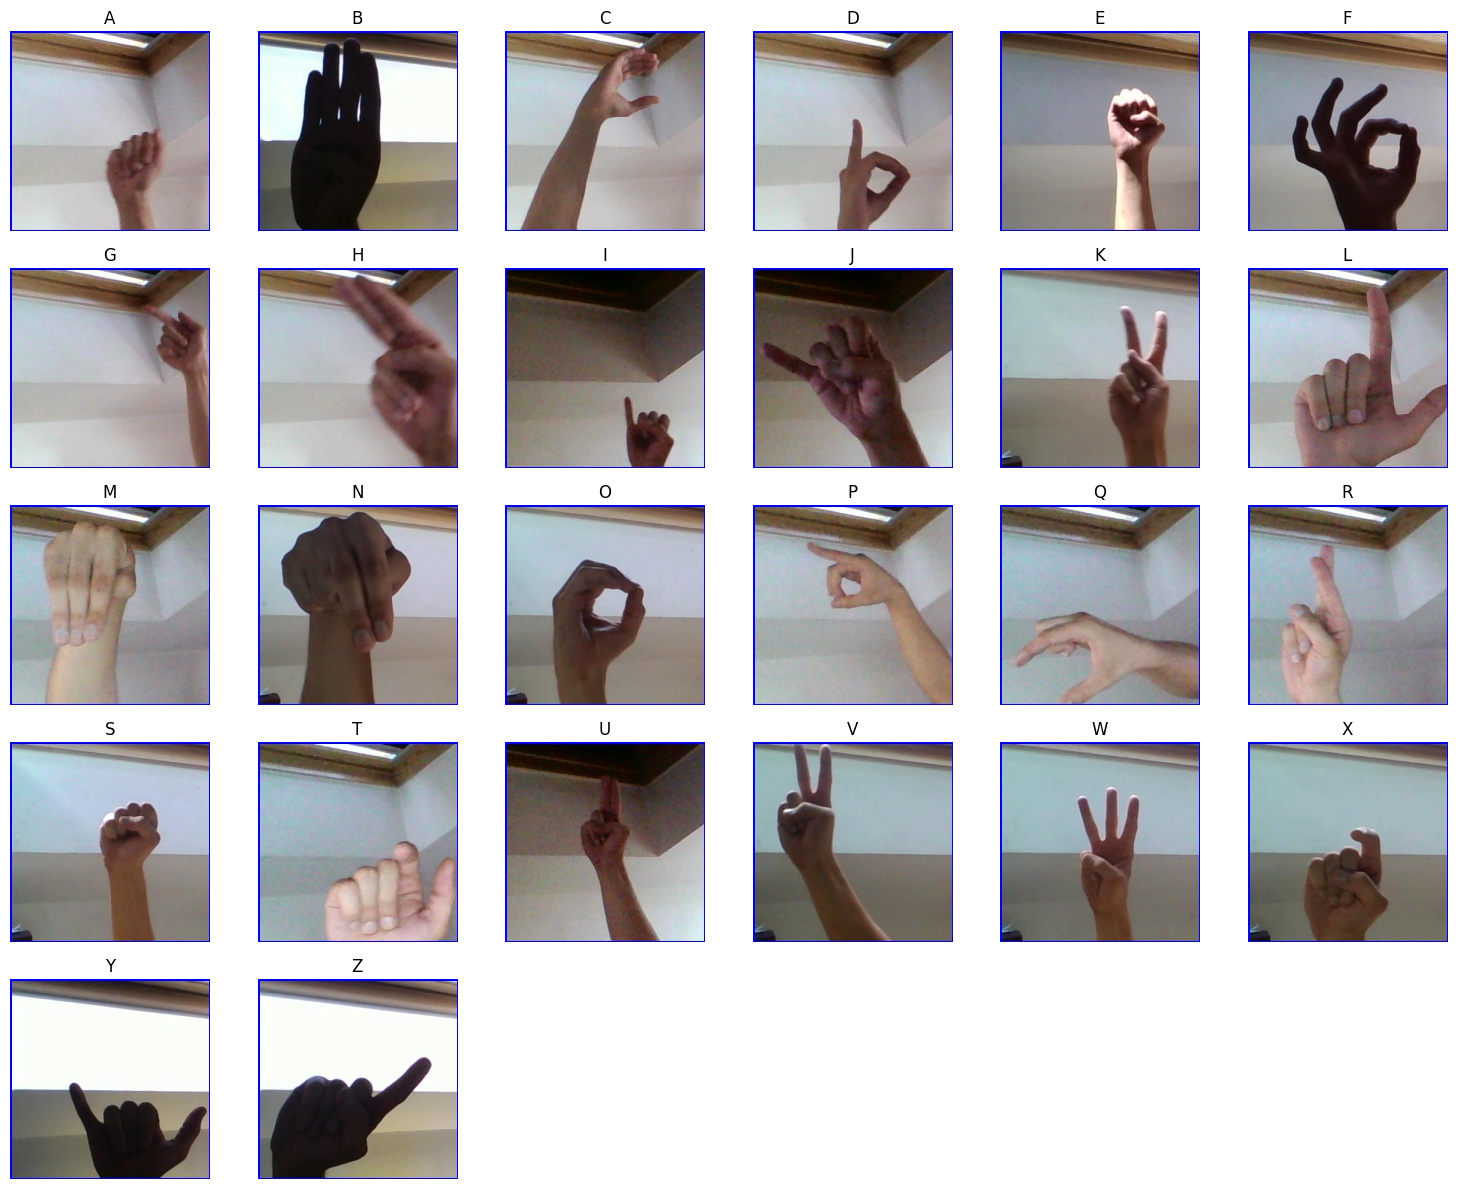

In [ ]:
fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()  # 2D grid ko simple list bana do

for i, letter in enumerate(labels[:26]):  # sirf A-Z
    letter_path = os.path.join(train_path, letter)
    img = mpimg.imread(os.path.join(letter_path, os.listdir(letter_path)[0]))
    axes[i].imshow(img)
    axes[i].set_title(letter, fontsize=12)
    axes[i].axis('off')

# bachi hui empty boxes band karo
for j in range(26, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Paths confirm karo
dataset_path = "/root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1"
train_path = os.path.join(dataset_path, "asl_alphabet_train", "asl_alphabet_train")
labels = sorted(os.listdir(train_path))

print("Train path ready!")
print("Total labels:", len(labels))

Train path ready!
Total labels: 29


In [ ]:
import urllib.request

urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
    "hand_landmarker.task"
)
print("Model downloaded")


Model downloaded


In [ ]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import mediapipe as mp

base_options = mp_python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)

with vision.HandLandmarker.create_from_options(options) as landmarker:
    sample_path = os.path.join(train_path, "A", os.listdir(os.path.join(train_path, "A"))[0])

    # Image yahan se aata hai
    mp_image = mp.Image.create_from_file(sample_path)
    result = landmarker.detect(mp_image)

    if result.hand_landmarks:
        print(f"Hand is detected!")
        print(f"Total landmarks: {len(result.hand_landmarks[0])}")
        print(f"Wrist (point 0): x={result.hand_landmarks[0][0].x:.3f}, y={result.hand_landmarks[0][0].y:.3f}")
    else:
        print("Hand is not detected")

Hand is detected!
Total landmarks: 21
Wrist (point 0): x=0.601, y=0.799


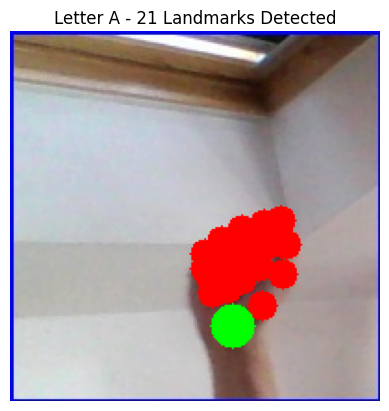

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Image load karo
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img_rgb.shape[:2]

# Sare 21 points draw karo
for landmark in result.hand_landmarks[0]:
    x = int(landmark.x * w)
    y = int(landmark.y * h)
    cv2.circle(img_rgb, (x, y), 8, (255, 0, 0), -1)

# Wrist ko alag color se highlight karo
wrist = result.hand_landmarks[0][0]
cv2.circle(img_rgb, (int(wrist.x * w), int(wrist.y * h)), 12, (0, 255, 0), -1)

plt.imshow(img_rgb)
plt.title("Letter A - 21 Landmarks Detected")
plt.axis('off')
plt.show()

In [ ]:
import csv

output_file = "landmarks_dataset.csv"
IMAGES_PER_LABEL = 200

with open(output_file, "w", newline="") as f:
    writer = csv.writer(f)

    # Header row
    header = []
    for i in range(21):
        header += [f"x{i}", f"y{i}", f"z{i}"]
    header.append("label")
    writer.writerow(header)

    base_options = mp_python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)

    with vision.HandLandmarker.create_from_options(options) as landmarker:
        for label in labels:
            label_path = os.path.join(train_path, label)
            images = os.listdir(label_path)[:IMAGES_PER_LABEL]
            count = 0

            for img_file in images:
                img_path = os.path.join(label_path, img_file)
                try:
                    mp_image = mp.Image.create_from_file(img_path)
                    result = landmarker.detect(mp_image)

                    if result.hand_landmarks:
                        row = []
                        for lm in result.hand_landmarks[0]:
                            row += [lm.x, lm.y, lm.z]
                        row.append(label)
                        writer.writerow(row)
                        count += 1
                except:
                    pass

            print(f"{label}: {count} images processed")

print("\nDataset saved to landmarks_dataset.csv!")

A: 135 images processed
B: 153 images processed
C: 125 images processed
D: 163 images processed
E: 162 images processed
F: 191 images processed
G: 161 images processed
H: 153 images processed
I: 155 images processed
J: 164 images processed
K: 183 images processed
L: 160 images processed
M: 107 images processed
N: 77 images processed
O: 150 images processed
P: 139 images processed
Q: 152 images processed
R: 165 images processed
S: 173 images processed
T: 144 images processed
U: 171 images processed
V: 172 images processed
W: 173 images processed
X: 142 images processed
Y: 172 images processed
Z: 154 images processed
del: 126 images processed
nothing: 0 images processed
space: 101 images processed

Dataset saved to landmarks_dataset.csv!


In [ ]:
import pandas as pd

df = pd.read_csv("landmarks_dataset.csv")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("\nImages per label:")
print(df['label'].value_counts())

Total rows: 4223
Total columns: 64

Images per label:
label
F        191
K        183
W        173
S        173
Y        172
V        172
U        171
R        165
J        164
D        163
E        162
G        161
L        160
I        155
Z        154
B        153
H        153
Q        152
O        150
T        144
X        142
P        139
A        135
del      126
C        125
M        107
space    101
N         77
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import numpy as np

# Features aur labels alag karo
X = df.drop('label', axis=1).values
y = df['label'].values

# Labels ko numbers mein convert karo (A=0, B=1, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train aur test split karo (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Total classes:", len(le.classes_))
print("Classes:", list(le.classes_))


Training samples: 3378
Testing samples: 845
Total classes: 28
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Labels one-hot encode karo
y_train_cat = to_categorical(y_train, num_classes=28)
y_test_cat = to_categorical(y_test, num_classes=28)

# Model banao
model = Sequential([
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(28, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,268 (71.36 KB)

 Trainable params: 18,268 (71.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0619 - loss: 3.2943 - val_accuracy: 0.1373 - val_loss: 3.1869
Epoch 2/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1625 - loss: 3.0264 - val_accuracy: 0.3124 - val_loss: 2.6963
Epoch 3/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2703 - loss: 2.5125 - val_accuracy: 0.5065 - val_loss: 2.1295
Epoch 4/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3801 - loss: 2.0517 - val_accuracy: 0.6533 - val_loss: 1.6621
Epoch 5/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4677 - loss: 1.7043 - val_accuracy: 0.7373 - val_loss: 1.3218
Epoch 6/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5480 - loss: 1.4473 - val_accuracy: 0.7527 - val_loss: 1.0808
Epoch 7/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6152 - loss: 1.2319 - val_accuracy: 0.8402 - val_loss: 0.9083
Epoch 8/50
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6690 - loss: 1.0684 - val_accuracy: 0.

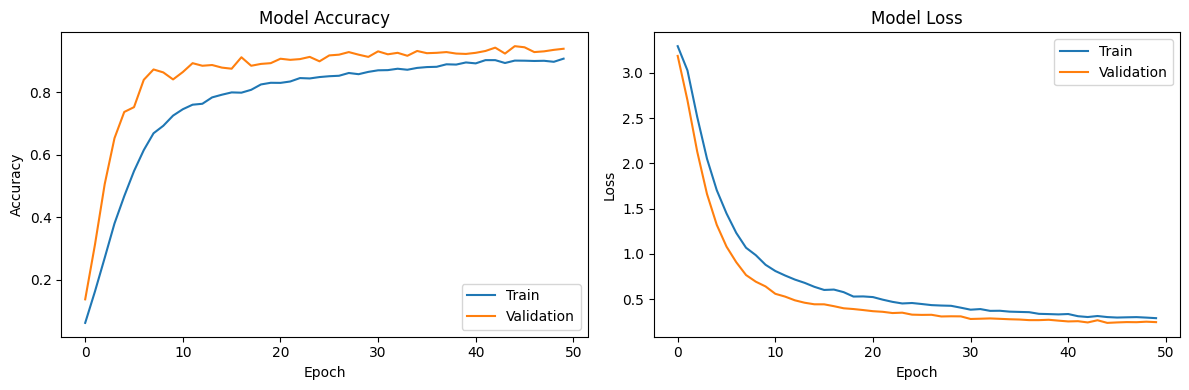

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Model save karo
model.save("asl_model.keras")

# Label encoder save karo (ye zaruri hai — numbers ko letters mein convert karta hai)
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("Model saved: asl_model.keras")
print("Label encoder saved: label_encoder.pkl")

Model saved: asl_model.keras
Label encoder saved: label_encoder.pkl


In [ ]:
from google.colab import files

files.download("asl_model.keras")
files.download("label_encoder.pkl")
files.download("landmarks_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>